# Severity Scoring and QA Decision Policy

**Purpose.** Trace the exact calculation that converts defect evidence into a severity level and Pass, Review, or Fail decision.

**Expected result.** Component scores, weighted contributions, policy examples across all severity bands, and a real end-to-end inspection decision.

**Platform connection.** These values drive recommendations, manual review, rework, reports, and analytics.

## Weighted formula

\[
	ext{Severity} = 0.30(	ext{Size}) + 0.25(	ext{Location}) + 0.25(	ext{Defect Type}) + 0.20(	ext{Detection Confidence})
\]

| Final score | Level | Default QA interpretation |
|---:|---|---|
| 80-100 | Critical | Reject and trigger immediate action |
| 60-79.99 | High | Fail; reject or rework |
| 40-59.99 | Medium | Manual review |
| 0-39.99 | Low | Pass only when no anomaly was detected |

A detected anomaly is never automatically passed merely because its weighted score is below 40. The runtime applies a final safety override and sends it to Review.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.severity import (
    DEFECT_TYPE_SCORES,
    calculate_severity_from_prediction,
    score_from_defect_area_ratio,
    score_from_location,
)

area_examples = [0, 0.003, 0.01, 0.03, 0.08]
display(
    pd.DataFrame(
        {
            "defect_area_ratio": area_examples,
            "area_percent": [value * 100 for value in area_examples],
            "size_score": [score_from_defect_area_ratio(value) for value in area_examples],
        }
    )
)
display(pd.DataFrame(sorted(DEFECT_TYPE_SCORES.items()), columns=["defect_type", "risk_score"]))
display(pd.DataFrame([{"critical_zone_overlap": False, "location_score": score_from_location(False)}, {"critical_zone_overlap": True, "location_score": score_from_location(True)}]))

,defect_area_ratio,area_percent,size_score
0,0.000,0.0,0
1,0.003,0.3,20
2,0.010,1.0,45
3,0.030,3.0,70
4,0.080,8.0,90


,defect_type,risk_score
0,bent,80
1,bent_lead,85
2,bent_wire,85
3,broken,90
4,broken_large,95
5,broken_small,75
6,broken_teeth,90
7,cable_swap,90
8,color,45
9,color_triple,70


,critical_zone_overlap,location_score
0,False,35
1,True,90


In [3]:
from dataclasses import replace

from ml.inference import apply_quality_decision
from ml.predict import build_inference_config

config = replace(build_inference_config("bottle"), review_severity_threshold=40.0, fail_severity_threshold=60.0)
examples = [
    {"name": "Normal product", "defect_type": "good", "confidence": 0.92, "area": 0.0, "critical": False, "detected": False},
    {"name": "Small scratch", "defect_type": "scratch", "confidence": 0.72, "area": 0.003, "critical": False, "detected": True},
    {"name": "Contamination", "defect_type": "contamination", "confidence": 0.86, "area": 0.018, "critical": False, "detected": True},
    {"name": "Large critical crack", "defect_type": "crack", "confidence": 0.97, "area": 0.07, "critical": True, "detected": True},
]

rows = []
example_results = {}
for item in examples:
    severity = calculate_severity_from_prediction(
        defect_type=item["defect_type"],
        confidence=item["confidence"],
        area_ratio=item["area"],
        is_critical_location=item["critical"],
    )
    final = apply_quality_decision(severity, config, is_defective=item["detected"])
    example_results[item["name"]] = final
    rows.append(
        {
            "case": item["name"],
            **final["components"],
            "severity_score": final["severity_score"],
            "severity_level": final["severity_level"],
            "direct_severity_decision": severity["pass_fail"],
            "final_runtime_decision": final["pass_fail"],
        }
    )
severity_df = pd.DataFrame(rows)
display(severity_df)

,case,size_score,location_score,defect_type_score,confidence_score,severity_score,severity_level,direct_severity_decision,final_runtime_decision
0,Normal product,0.0,0.0,0.0,0.0,0.00,Low,Pass,Pass
1,Small scratch,20.0,35.0,35.0,72.0,37.90,Low,Pass,Review
2,Contamination,45.0,35.0,55.0,86.0,53.20,Medium,Review,Review
3,Large critical crack,90.0,90.0,95.0,97.0,92.65,Critical,Fail,Fail


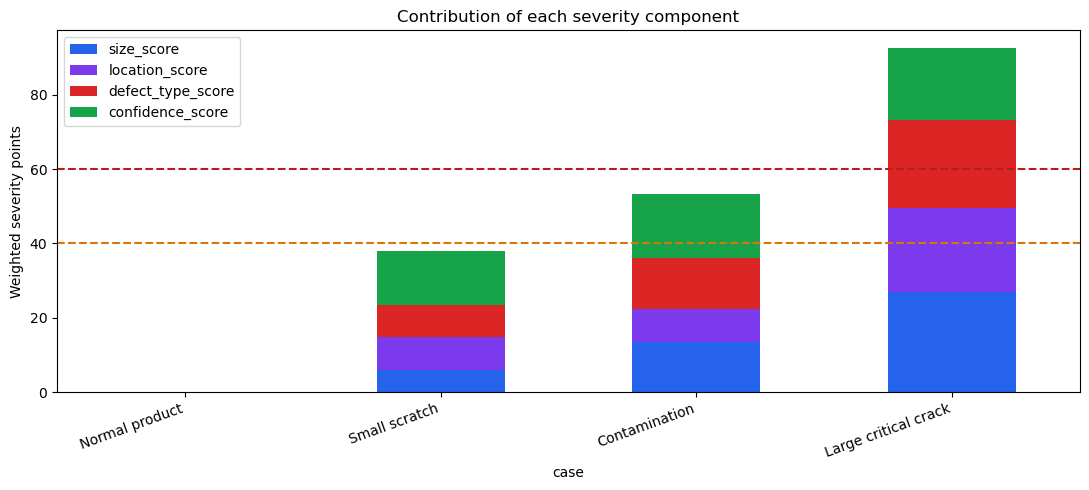

In [4]:
selected = severity_df.set_index("case")[
    ["size_score", "location_score", "defect_type_score", "confidence_score"]
]
weighted = selected.mul([0.30, 0.25, 0.25, 0.20], axis=1)
ax = weighted.plot(kind="bar", stacked=True, figsize=(11, 5), color=["#2563eb", "#7c3aed", "#dc2626", "#16a34a"])
ax.axhline(40, color="#d97706", linestyle="--", label="Review threshold")
ax.axhline(60, color="#b91c1c", linestyle="--", label="Fail threshold")
ax.set_ylabel("Weighted severity points")
ax.set_title("Contribution of each severity component")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [5]:
from ml.inference import inspect_image as inspect_image_runtime

category = "bottle"
label, path = first_defect(category)
portable_config = replace(
    build_inference_config(category),
    use_padim_inference=False,
    use_openvino_inference=False,
    openvino_path=None,
    openvino_calibrator_path=None,
    critical_zones=("center",),
)
result = inspect_image_runtime(path, portable_config)
decision_view = {
    "input": str(path),
    "prediction": result["prediction"],
    "defect_type": result["defect_type"],
    "detection_confidence": result["detection_confidence"],
    "defect_area_ratio": result["defect_area_ratio"],
    "severity_components": result["severity_components"],
    "severity_score": result["severity_score"],
    "severity_level": result["severity_level"],
    "decision": result["decision"],
    "recommended_action": result["recommended_action"],
    "explanation": result["explainability"]["notes"],
}
display(JSON(decision_view))

<IPython.core.display.JSON object>

## What this demonstrates

- Size is derived from the localized mask, not the filename or class label.
- Location becomes critical only when detected regions overlap product-specific configured critical zones.
- Defect-type scores encode QA risk and cover the MVTec subtype vocabulary used by the project.
- Detection confidence contributes to severity, while subtype confidence remains a separate explainability field.
- The final policy prevents any detected anomaly from silently passing below the Review threshold.